# Exploratory Data Analysis

Goal: understand the data well enough to make informed preprocessing and 
modelling decisions. Each section answers a specific question.

In [1]:
%pip install pandas scikit-learn matplotlib seaborn -q

import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data, CONTINUOUS_FEATURES, BINARY_FEATURES, TARGET

# Consistent plot style throughout
sns.set_theme(style="whitegrid")

# Load
df = load_data()
print(df.shape)


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
(1000000, 8)


## Basic profile

A first look at the data: types, nulls, and summary statistics.

In [2]:
print(df.dtypes)
print(f"\nNull values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nClass balance:")
print(df[TARGET].value_counts())
print(f"\nFraud rate: {df[TARGET].mean():.4f}")

distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                      int8
used_chip                            int8
used_pin_number                      int8
online_order                         int8
fraud                                int8
dtype: object

Null values: 0
Duplicate rows: 0

Class balance:
fraud
0    912597
1     87403
Name: count, dtype: int64

Fraud rate: 0.0874


## Continuous features: summary statistics

In [3]:
df[CONTINUOUS_FEATURES].describe().round(2)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price
count,1000000.00,1000000.00,1000000.00
mean,26.63,5.04,1.82
std,65.39,25.84,2.80
min,0.00,0.00,0.00
25%,3.88,0.30,0.48
50%,9.97,1.00,1.00
75%,25.74,3.36,2.10
max,10632.72,11851.10,267.80


## Continuous features: distributions

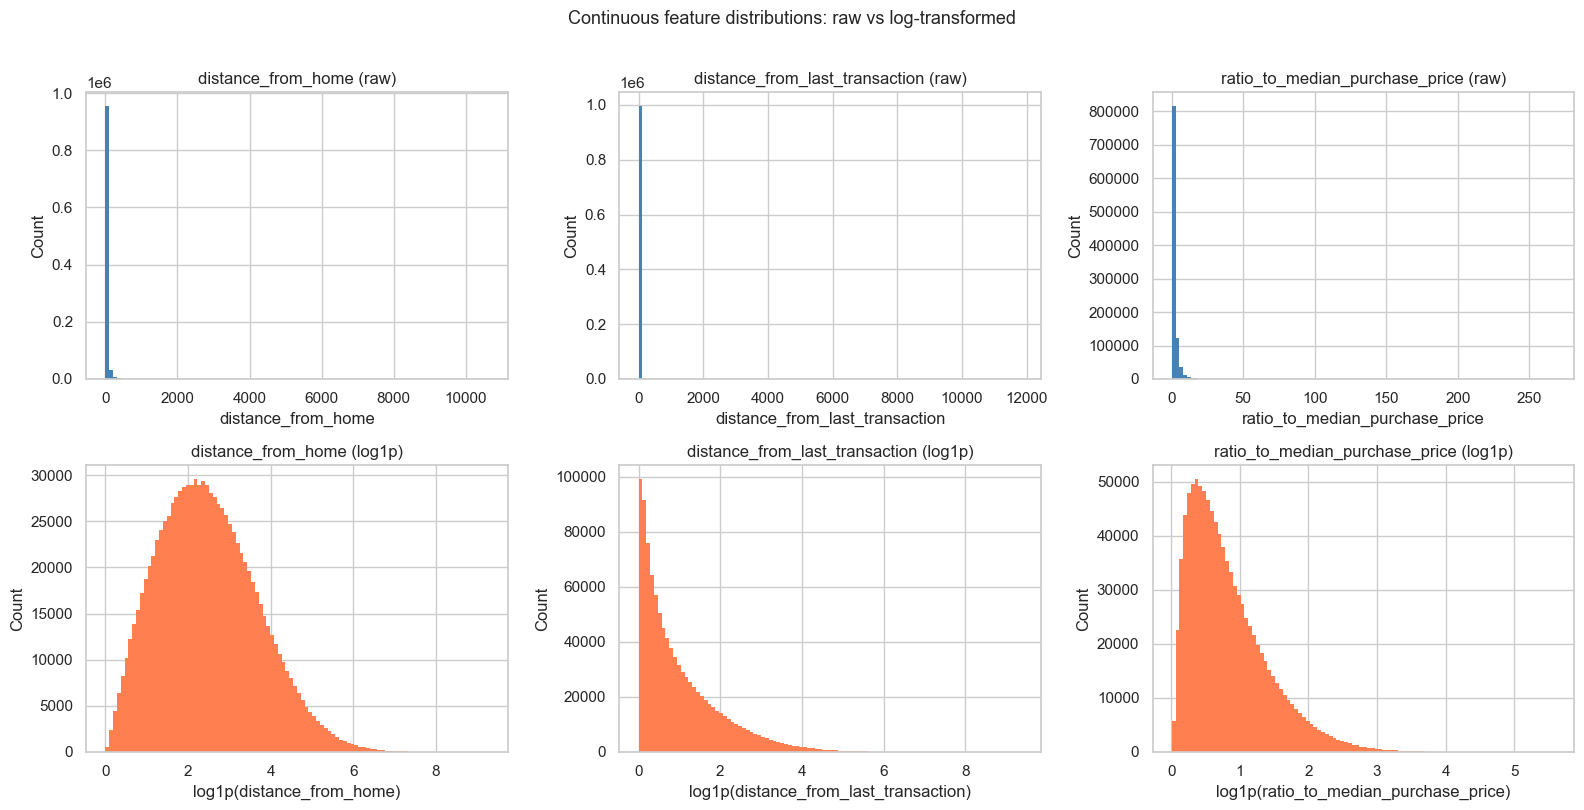

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(CONTINUOUS_FEATURES):
    # Raw distribution
    axes[0, i].hist(df[col], bins=100, color='steelblue', edgecolor='none')
    axes[0, i].set_title(f'{col} (raw)')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Count')

    # Log-transformed distribution
    axes[1, i].hist(np.log1p(df[col]), bins=100, color='coral', edgecolor='none')
    axes[1, i].set_title(f'{col} (log1p)')
    axes[1, i].set_xlabel(f'log1p({col})')
    axes[1, i].set_ylabel('Count')

plt.suptitle('Continuous feature distributions: raw vs log-transformed', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_continuous_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()

## Class balance

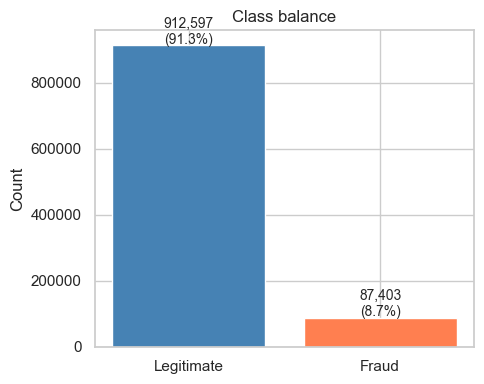

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET].value_counts()
ax.bar(['Legitimate', 'Fraud'], counts.values, color=['steelblue', 'coral'])
ax.set_ylabel('Count')
ax.set_title('Class balance')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5000, f'{v:,}\n({v/len(df)*100:.1f}%)', 
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../reports/figures/02_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

## Binary features: fraud rate by category

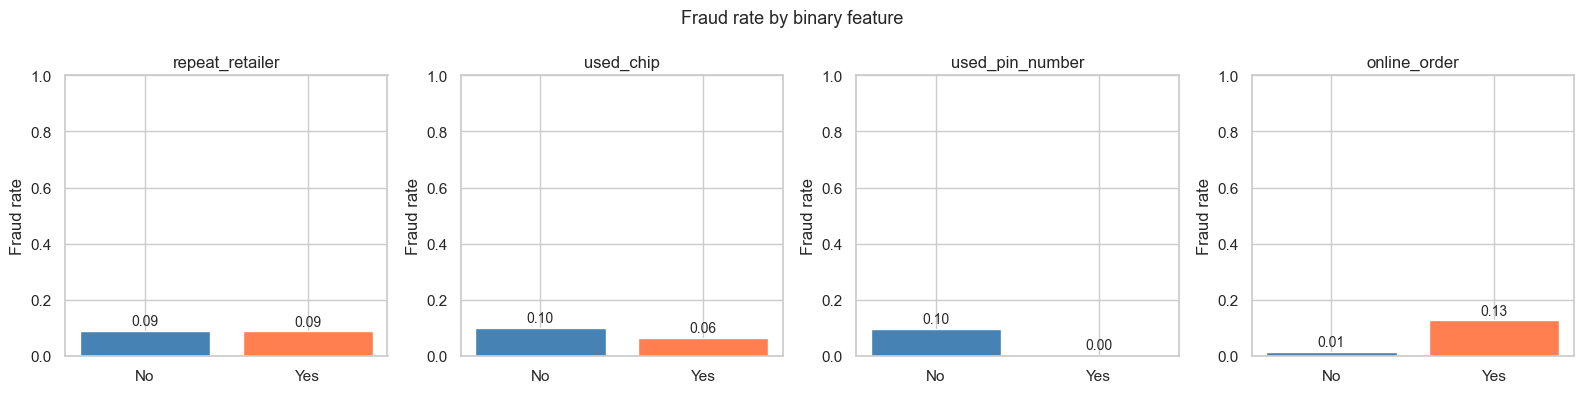

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(BINARY_FEATURES):
    fraud_rate = df.groupby(col)[TARGET].mean().reset_index()
    axes[i].bar(
        fraud_rate[col].map({0: 'No', 1: 'Yes'}),
        fraud_rate[TARGET],
        color=['steelblue', 'coral']
    )
    axes[i].set_title(col)
    axes[i].set_ylabel('Fraud rate')
    axes[i].set_ylim(0, 1)
    for j, row in fraud_rate.iterrows():
        axes[i].text(j, row[TARGET] + 0.02, 
                     f"{row[TARGET]:.2f}", ha='center', fontsize=10)

plt.suptitle('Fraud rate by binary feature', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/03_binary_fraud_rates.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlations

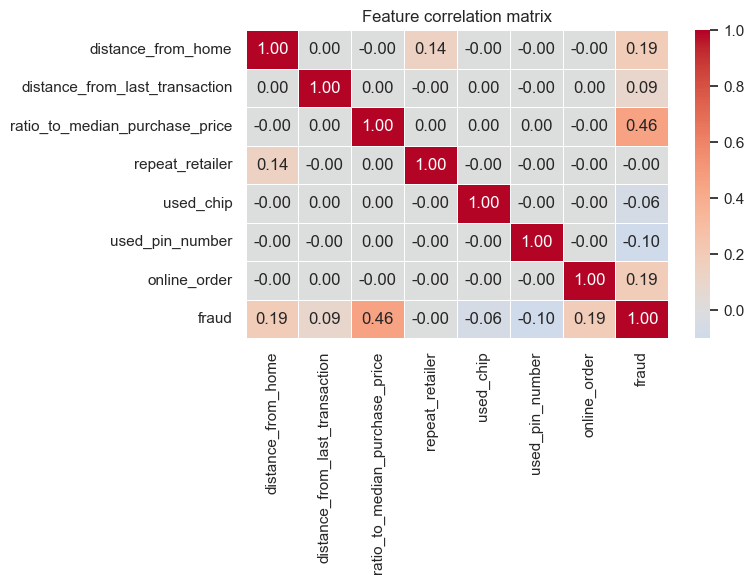

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
corr = df.corr(numeric_only=True).round(2)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('../reports/figures/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Continuous features: fraud vs legitimate

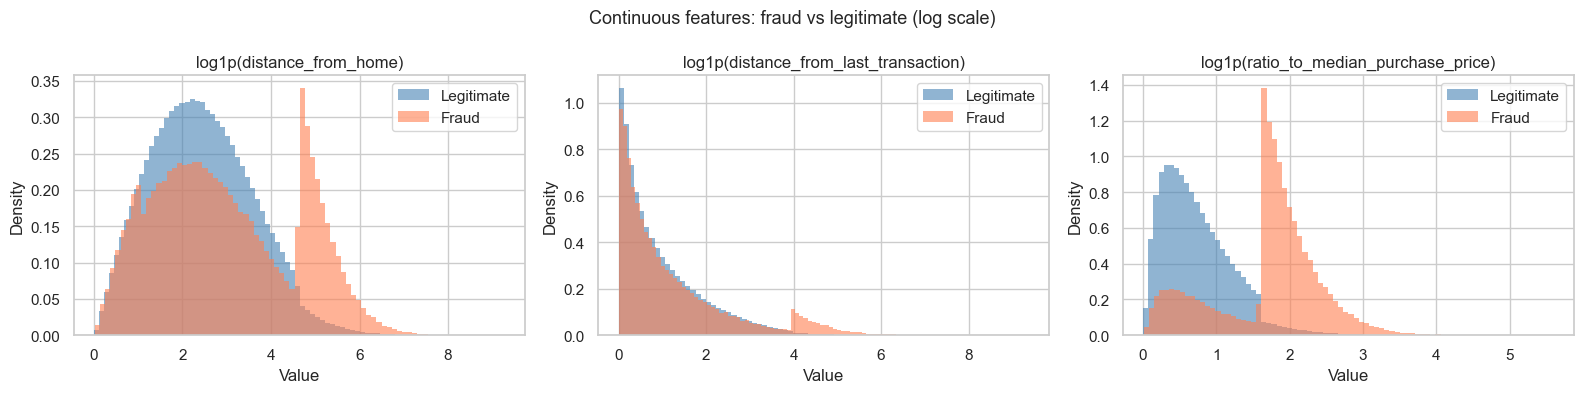

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(CONTINUOUS_FEATURES):
    for label, colour in zip([0, 1], ['steelblue', 'coral']):
        axes[i].hist(
            np.log1p(df[df[TARGET] == label][col]),
            bins=80, alpha=0.6, color=colour,
            label='Legitimate' if label == 0 else 'Fraud',
            density=True, edgecolor='none'
        )
    axes[i].set_title(f'log1p({col})')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Continuous features: fraud vs legitimate (log scale)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/05_continuous_by_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

### Distributions (Chart 1). 
The raw plots confirm what the stats told us in our EDA. All three features are completely dominated by low values with extreme tails and thus almost unworkable in raw form for linear models. The log-transformed versions are far more reasonable, though still right-skewed. The decision is clear: log-transform all three continuous features in Phase 2. We then use log1p (which handles zeros cleanly), as shown above.

### Class balance (Chart 2). 
91.3% legitimate versus 8.7% fraud. Worth keeping in mind that a model which predicts "legitimate" for every single transaction would be 91.3% accurate. That is why accuracy is may be the wrong metric here maybe we use precision-recall AUC instead?

### Binary features (Chart 3). Important. 

- `used_pin_number` is striking. When a PIN is used, the fraud rate basically drops to zero. This is clearly the strongest protective signal in this dataset. Mh.
- `online_order` is the strongest positive predictor. Online orders have a 13% fraud rate vs 1% for in-person so an online transaction is 13 times more likely to be fraudulent.
- `repeat_retailer` makes no difference at all. Fraud rate is 0.09 whether the retailer is familiar or not. This feature carries almost no signal.
- `used_chip` has a modest effect. Chip transactions have a slightly lower fraud rate (0.06 vs 0.10), which makes intuitive sense since chip cards are harder to clone.


### Correlation matrix (Chart 4). 
`ratio_to_median_purchase_price` has a 0.46 correlation with fraud, by far the highest of any feature. `distance_from_home` and `online_order` both sit at 0.19. `used_pin_number` is -0.10, confirming it is protective. Crucially, inter-feature correlations are near zero across the board, which means no multicollinearity to worry about. Each feature is contributing independent information.

### Fraud vs legitimate by feature (Chart 5). 
Fraud transactions happen further from home (the orange distribution is shifted right on the log scale). For `distance_from_last_transaction` the distributions overlap heavily, making it a weaker separator. For `ratio_to_median_purchase_price` the separation is clear: fraud transactions cluster at higher ratios, which aligns with the 0.46 correlation.

One thing these charts collectively confirm: the classes are highly separable. Between `used_pin_number` being near-zero for fraud, `online_order` being a strong positive signal, and `ratio_to_median_purchase_price` having a 0.46 correlation, a basic model should score very well. 